# Extensii experimentale — partea practică (v2)

Acest notebook extinde studiul de bază cu trei componente menite să consolideze validitatea metodologică a lucrării de disertație:

1. **Scenariul D — design factorial**: variația simultană a dimensionalității și a zgomotului, pentru a studia *interacțiunile* dintre cei doi factori (lacună identificată în literatura SLR).
2. **Validare pe date reale (UCI)**: replicarea analizei pe setul *Breast Cancer Wisconsin*, pentru a verifica dacă tendințele observate pe date sintetice se confirmă în condiții realiste.
3. **Testare statistică**: aplicarea testului **Friedman** și a procedurii post-hoc **Nemenyi / Wilcoxon-Holm** pentru a stabili dacă diferențele de performanță dintre modele sunt semnificative statistic (metodologie Demšar, 2006).

> **Recomandare:** a se rula mai întâi notebook-ul original `experimente_disertatie.ipynb` pentru a genera CSV-urile cu rezultatele scenariilor A, B și C. Acest notebook le folosește în secțiunea de testare statistică.


## 1. Setup și importuri

In [1]:
# (Opțional) instalare scikit-posthocs pentru testele post-hoc avansate.
# Daca nu poate fi instalat, notebook-ul foloseste fallback bazat pe Wilcoxon + Holm.
# !pip install scikit-posthocs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
from pathlib import Path
from itertools import product

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from scipy import stats
from scipy.stats import friedmanchisquare, rankdata, wilcoxon

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Configurare globala
RANDOM_SEED = 42
N_SAMPLES = 1000
N_REPEATS = 5
CV_FOLDS = 5
np.random.seed(RANDOM_SEED)

RESULTS_DIR = Path("rezultate")
RESULTS_DIR.mkdir(exist_ok=True)
print(f"Director rezultate: {RESULTS_DIR.absolute()}")


Director rezultate: d:\disertatie_practica\rezultate


## 2. Modele (configurare identica cu notebook-ul de baza)

In [2]:
def get_models(random_state=42):
    return {
        "Regresie Logistica": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=random_state)),
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=5)),
        ]),
        "SVM (RBF)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", gamma="scale", C=1.0, random_state=random_state)),
        ]),
        "Random Forest": RandomForestClassifier(
            n_estimators=100, random_state=random_state, n_jobs=-1
        ),
        "Retea Neuronala (MLP)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(hidden_layer_sizes=(64,), max_iter=500,
                                  random_state=random_state)),
        ]),
    }

def evaluate_models(X, y, models, cv_folds=CV_FOLDS, cv_seed=42):
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=cv_seed)
    scoring = ["accuracy", "f1", "roc_auc"]
    out = {}
    for name, model in models.items():
        t0 = time.time()
        scores = cross_validate(model, X, y, cv=cv, scoring=scoring,
                                n_jobs=-1, return_train_score=False)
        elapsed = time.time() - t0
        out[name] = {
            "accuracy_mean": scores["test_accuracy"].mean(),
            "accuracy_std":  scores["test_accuracy"].std(),
            "f1_mean":       scores["test_f1"].mean(),
            "auc_mean":      scores["test_roc_auc"].mean(),
            "train_time":    elapsed,
        }
    return out


## 3. Scenariul D — Design factorial: dimensionalitate × zgomot

Variem simultan `n_features ∈ {10, 50, 100, 200}` și `flip_y ∈ {0.00, 0.10, 0.20, 0.30}`, rezultând **16 combinații** × `N_REPEATS=5` repetări × 5 modele × 5-fold CV. Permite observarea **interacțiunilor** dintre cei doi factori — întrebare deschisă în literatură.


In [3]:
N_FEATURES_GRID = [10, 50, 100, 200]
FLIP_Y_GRID      = [0.00, 0.10, 0.20, 0.30]

def build_dataset_D(n_features, flip_y, seed):
    n_informative = max(2, n_features // 2)
    X, y = make_classification(
        n_samples=N_SAMPLES,
        n_features=n_features,
        n_informative=n_informative,
        n_redundant=0,
        n_repeated=0,
        n_classes=2,
        flip_y=flip_y,
        class_sep=1.0,
        random_state=seed,
    )
    return X, y

rows = []
combos = list(product(N_FEATURES_GRID, FLIP_Y_GRID))
total = len(combos) * N_REPEATS
step = 0

print("Pornesc Scenariul D — factorial...")
for n_features, flip_y in combos:
    for rep in range(N_REPEATS):
        step += 1
        seed = rep * 100 + 7
        X, y = build_dataset_D(n_features, flip_y, seed)
        models = get_models(random_state=seed)
        results = evaluate_models(X, y, models, cv_seed=seed)
        for model_name, metrics in results.items():
            row = {
                "n_features": n_features,
                "flip_y": flip_y,
                "repetitie": rep,
                "model": model_name,
            }
            row.update(metrics)
            rows.append(row)
        print(f"  [{step:>3}/{total}] n_features={n_features}, flip_y={flip_y}, rep={rep} — done")

df_D = pd.DataFrame(rows)
df_D.to_csv(RESULTS_DIR / "scenariu_D_factorial.csv", index=False)
print(f"\nSalvat: scenariu_D_factorial.csv ({len(df_D)} randuri)")
df_D.head()


Pornesc Scenariul D — factorial...
  [  1/80] n_features=10, flip_y=0.0, rep=0 — done
  [  2/80] n_features=10, flip_y=0.0, rep=1 — done
  [  3/80] n_features=10, flip_y=0.0, rep=2 — done
  [  4/80] n_features=10, flip_y=0.0, rep=3 — done
  [  5/80] n_features=10, flip_y=0.0, rep=4 — done
  [  6/80] n_features=10, flip_y=0.1, rep=0 — done
  [  7/80] n_features=10, flip_y=0.1, rep=1 — done
  [  8/80] n_features=10, flip_y=0.1, rep=2 — done
  [  9/80] n_features=10, flip_y=0.1, rep=3 — done
  [ 10/80] n_features=10, flip_y=0.1, rep=4 — done
  [ 11/80] n_features=10, flip_y=0.2, rep=0 — done
  [ 12/80] n_features=10, flip_y=0.2, rep=1 — done
  [ 13/80] n_features=10, flip_y=0.2, rep=2 — done
  [ 14/80] n_features=10, flip_y=0.2, rep=3 — done
  [ 15/80] n_features=10, flip_y=0.2, rep=4 — done
  [ 16/80] n_features=10, flip_y=0.3, rep=0 — done
  [ 17/80] n_features=10, flip_y=0.3, rep=1 — done
  [ 18/80] n_features=10, flip_y=0.3, rep=2 — done
  [ 19/80] n_features=10, flip_y=0.3, rep=3 — d

,n_features,flip_y,repetitie,model,accuracy_mean,accuracy_std,f1_mean,auc_mean,train_time
0,10,0.0,0,Regresie Logistica,0.831,0.030232,0.828868,0.90844,5.651757
1,10,0.0,0,KNN,0.853,0.019647,0.848715,0.93647,4.482946
2,10,0.0,0,SVM (RBF),0.918,0.016613,0.918920,0.96456,4.379911
3,10,0.0,0,Random Forest,0.874,0.016852,0.872590,0.95494,4.639207
4,10,0.0,0,Retea Neuronala (MLP),0.906,0.011576,0.905006,0.96330,2.256134


### 3.1. Sinteză factorial — tabel medii

In [4]:
summary_D = (df_D.groupby(["n_features", "flip_y", "model"])
                  .agg(accuracy_mean=("accuracy_mean", "mean"),
                       accuracy_std=("accuracy_mean", "std"),
                       f1_mean=("f1_mean", "mean"),
                       auc_mean=("auc_mean", "mean"))
                  .round(3)
                  .reset_index())
summary_D.to_csv(RESULTS_DIR / "scenariu_D_sumar.csv", index=False)
summary_D.head(20)


,n_features,flip_y,model,accuracy_mean,accuracy_std,f1_mean,auc_mean
0,10,0.0,KNN,0.871,0.052,0.872,0.941
1,10,0.0,Random Forest,0.900,0.030,0.900,0.967
2,10,0.0,Regresie Logistica,0.827,0.070,0.827,0.896
3,10,0.0,Retea Neuronala (MLP),0.926,0.030,0.926,0.978
4,10,0.0,SVM (RBF),0.908,0.046,0.909,0.965
5,10,0.1,KNN,0.823,0.044,0.822,0.882
6,10,0.1,Random Forest,0.859,0.023,0.857,0.917
7,10,0.1,Regresie Logistica,0.794,0.066,0.792,0.858
8,10,0.1,Retea Neuronala (MLP),0.862,0.031,0.861,0.915
9,10,0.1,SVM (RBF),0.864,0.044,0.864,0.913


### 3.2. Heatmap-uri factorial — un heatmap per model

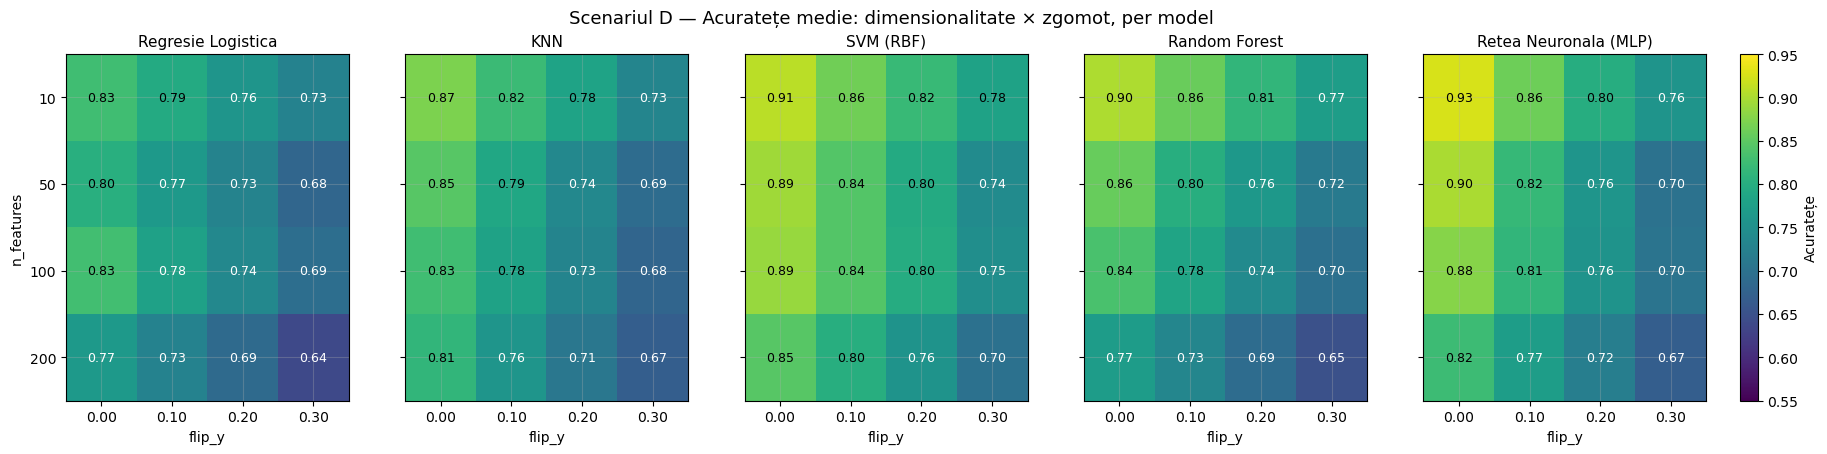

In [5]:
model_names = df_D["model"].unique()
fig, axes = plt.subplots(1, len(model_names), figsize=(22, 4.5), sharey=True)

vmin, vmax = 0.55, 0.95
for ax, model in zip(axes, model_names):
    sub = (df_D[df_D["model"] == model]
           .groupby(["n_features", "flip_y"])["accuracy_mean"]
           .mean().reset_index())
    pivot = sub.pivot(index="n_features", columns="flip_y", values="accuracy_mean")
    im = ax.imshow(pivot.values, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{v:.2f}" for v in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("flip_y")
    ax.set_title(model, fontsize=11)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.2f}",
                    ha="center", va="center", fontsize=9,
                    color="white" if pivot.values[i, j] < 0.78 else "black")
axes[0].set_ylabel("n_features")
fig.suptitle("Scenariul D — Acuratețe medie: dimensionalitate × zgomot, per model",
             fontsize=13)
fig.colorbar(im, ax=axes, fraction=0.018, pad=0.02, label="Acuratețe")
plt.savefig(RESULTS_DIR / "scenariu_D_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.3. Detectarea interacțiunilor

Dacă efectele celor doi factori ar fi *aditive*, am putea prezice acuratețea la `(n_features, flip_y)` ca sumă a contribuțiilor individuale. Discrepanța = efect de interacțiune.

In [6]:
def compute_interaction(df, model):
    sub = (df[df["model"] == model]
           .groupby(["n_features", "flip_y"])["accuracy_mean"]
           .mean().reset_index())
    # Acuratetea de baza (n_features=min, flip_y=0)
    base = sub[(sub.n_features == N_FEATURES_GRID[0]) &
               (sub.flip_y == FLIP_Y_GRID[0])]["accuracy_mean"].values[0]
    # Efect marginal n_features (la flip_y=0)
    eff_n = sub[sub.flip_y == FLIP_Y_GRID[0]].set_index("n_features")["accuracy_mean"] - base
    # Efect marginal flip_y (la n_features=min)
    eff_f = sub[sub.n_features == N_FEATURES_GRID[0]].set_index("flip_y")["accuracy_mean"] - base
    # Predictie aditiva si interactiune
    rows = []
    for n in N_FEATURES_GRID:
        for f in FLIP_Y_GRID:
            actual = sub[(sub.n_features == n) & (sub.flip_y == f)]["accuracy_mean"].values[0]
            predicted = base + eff_n.loc[n] + eff_f.loc[f]
            rows.append({"n_features": n, "flip_y": f,
                         "actual": actual, "additive_pred": predicted,
                         "interactiune": actual - predicted})
    return pd.DataFrame(rows)

# Pentru fiecare model, valoarea maxima a |interactiunii| ne arata cat de neaditivi sunt factorii
print("Magnitudinea maxima a interactiunii (|actual - aditiv|):\n")
for m in model_names:
    inter = compute_interaction(df_D, m)
    max_int = inter["interactiune"].abs().max()
    print(f"  {m:25s}: max |interactiune| = {max_int:.3f}")


Magnitudinea maxima a interactiunii (|actual - aditiv|):

  Regresie Logistica       : max |interactiune| = 0.036
  KNN                      : max |interactiune| = 0.021
  SVM (RBF)                : max |interactiune| = 0.023
  Random Forest            : max |interactiune| = 0.017
  Retea Neuronala (MLP)    : max |interactiune| = 0.029


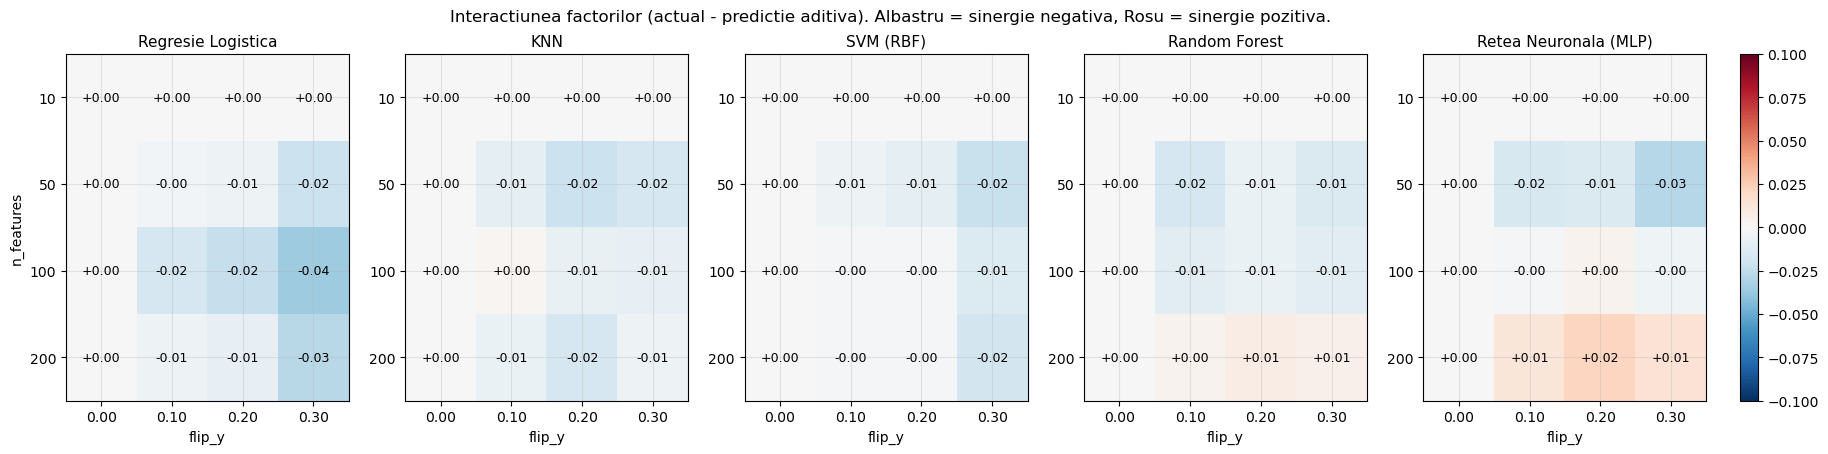

In [7]:
# Heatmap al interactiunilor pentru fiecare model
fig, axes = plt.subplots(1, len(model_names), figsize=(22, 4.5))
for ax, model in zip(axes, model_names):
    inter = compute_interaction(df_D, model)
    pivot = inter.pivot(index="n_features", columns="flip_y", values="interactiune")
    im = ax.imshow(pivot.values, cmap="RdBu_r", aspect="auto", vmin=-0.1, vmax=0.1)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{v:.2f}" for v in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("flip_y")
    ax.set_title(model, fontsize=11)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:+.2f}",
                    ha="center", va="center", fontsize=9)
axes[0].set_ylabel("n_features")
fig.suptitle("Interactiunea factorilor (actual - predictie aditiva). "
             "Albastru = sinergie negativa, Rosu = sinergie pozitiva.", fontsize=12)
fig.colorbar(im, ax=axes, fraction=0.018, pad=0.02)
plt.savefig(RESULTS_DIR / "scenariu_D_interactiuni.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Validare pe date reale — Breast Cancer Wisconsin

Setul **Breast Cancer Wisconsin** (UCI, prin scikit-learn): 569 instanțe, 30 atribute continue, două clase (benign/malign). Replicăm pe acest set:

- **Baseline** — performanță fără modificări (versiune curată).
- **Scenariu B' pe date reale** — adăugăm progresiv zgomot în etichete (`flip_y_simulat ∈ {0.05, 0.10, 0.20, 0.30}`) pentru a verifica robustețea modelelor.
- **Scenariu A' pe date reale** — reducem progresiv numărul de atribute (selectând primele *k* coloane) pentru a vedea cum se comportă fiecare model cu mai puțină informație.

Comparăm tendințele cu cele observate pe date sintetice.


In [8]:
# Incarcare set real
data = load_breast_cancer()
X_real, y_real = data.data, data.target
print(f"Set: Breast Cancer Wisconsin")
print(f"Instante: {X_real.shape[0]}, Atribute: {X_real.shape[1]}")
print(f"Distributia claselor: {np.bincount(y_real)} (0=malign, 1=benign)")


Set: Breast Cancer Wisconsin
Instante: 569, Atribute: 30
Distributia claselor: [212 357] (0=malign, 1=benign)


### 4.1. Baseline pe date reale curate

In [9]:
models = get_models(random_state=42)
baseline = evaluate_models(X_real, y_real, models, cv_seed=42)
baseline_df = pd.DataFrame(baseline).T.round(3)
baseline_df.to_csv(RESULTS_DIR / "uci_baseline.csv")
print("Baseline — Breast Cancer Wisconsin (datele originale):")
baseline_df


Baseline — Breast Cancer Wisconsin (datele originale):


,accuracy_mean,accuracy_std,f1_mean,auc_mean,train_time
Regresie Logistica,0.974,0.017,0.979,0.995,0.066
KNN,0.963,0.018,0.971,0.985,0.040
SVM (RBF),0.977,0.016,0.982,0.995,0.049
Random Forest,0.956,0.012,0.965,0.989,0.542
Retea Neuronala (MLP),0.982,0.008,0.986,0.996,1.036


### 4.2. Robustețea modelelor la zgomot artificial introdus în etichete

In [10]:
def corrupt_labels(y, flip_y, random_state):
    rng = np.random.RandomState(random_state)
    y_noisy = y.copy()
    n = len(y)
    n_flip = int(round(flip_y * n))
    flip_idx = rng.choice(n, size=n_flip, replace=False)
    # pentru clase binare: inversam eticheta
    y_noisy[flip_idx] = 1 - y_noisy[flip_idx]
    return y_noisy

FLIP_LEVELS = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
rows_uci_noise = []

for flip_y in FLIP_LEVELS:
    for rep in range(N_REPEATS):
        seed = rep * 100 + 7
        y_noisy = corrupt_labels(y_real, flip_y, random_state=seed)
        models = get_models(random_state=seed)
        results = evaluate_models(X_real, y_noisy, models, cv_seed=seed)
        for model_name, metrics in results.items():
            row = {"flip_y": flip_y, "repetitie": rep, "model": model_name}
            row.update(metrics)
            rows_uci_noise.append(row)
    print(f"  flip_y={flip_y} — done")

df_uci_noise = pd.DataFrame(rows_uci_noise)
df_uci_noise.to_csv(RESULTS_DIR / "uci_zgomot.csv", index=False)
print(f"\nSalvat: uci_zgomot.csv ({len(df_uci_noise)} randuri)")


  flip_y=0.0 — done
  flip_y=0.05 — done
  flip_y=0.1 — done
  flip_y=0.15 — done
  flip_y=0.2 — done
  flip_y=0.25 — done
  flip_y=0.3 — done

Salvat: uci_zgomot.csv (175 randuri)


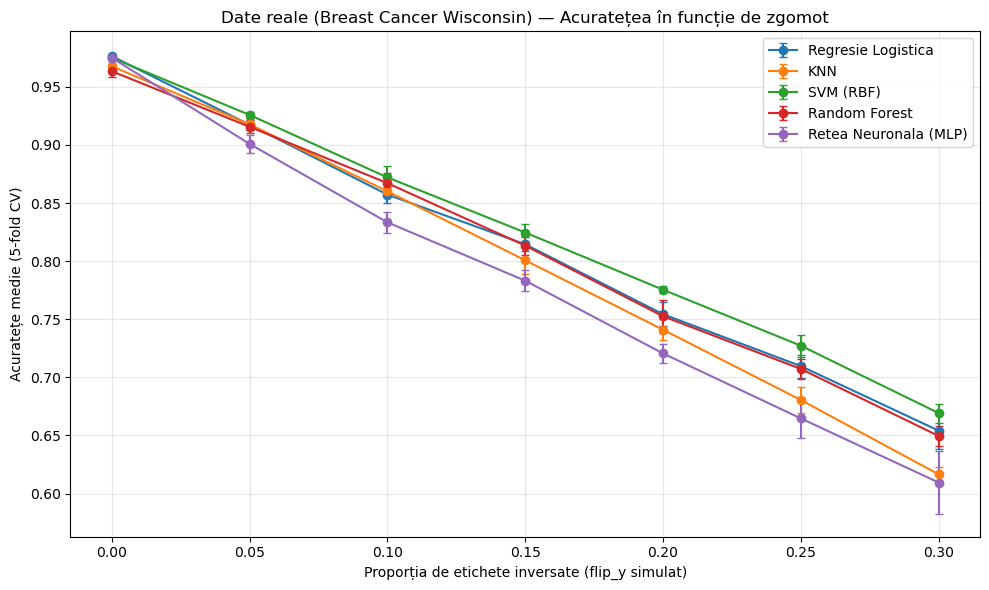

In [11]:
# Grafic acuratete vs flip_y pentru UCI
fig, ax = plt.subplots(figsize=(10, 6))
for m in df_uci_noise["model"].unique():
    sub = (df_uci_noise[df_uci_noise["model"] == m]
           .groupby("flip_y")["accuracy_mean"]
           .agg(["mean", "std"]).reset_index())
    ax.errorbar(sub["flip_y"], sub["mean"], yerr=sub["std"],
                marker="o", capsize=3, label=m)
ax.set_title("Date reale (Breast Cancer Wisconsin) — Acuratețea în funcție de zgomot")
ax.set_xlabel("Proporția de etichete inversate (flip_y simulat)")
ax.set_ylabel("Acuratețe medie (5-fold CV)")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "uci_zgomot_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.3. Reducerea numărului de atribute (replicare Scenariu A pe date reale)

In [12]:
# Selectam progresiv un subset de atribute, pastrand toate instantele
N_FEAT_REAL = [5, 10, 15, 20, 25, 30]
rows_uci_dim = []

for k in N_FEAT_REAL:
    for rep in range(N_REPEATS):
        seed = rep * 100 + 7
        # Alegem aleatoriu k atribute pentru fiecare repetitie
        rng = np.random.RandomState(seed)
        cols = rng.choice(X_real.shape[1], size=k, replace=False)
        X_sub = X_real[:, cols]
        models = get_models(random_state=seed)
        results = evaluate_models(X_sub, y_real, models, cv_seed=seed)
        for model_name, metrics in results.items():
            row = {"n_features": k, "repetitie": rep, "model": model_name}
            row.update(metrics)
            rows_uci_dim.append(row)
    print(f"  k={k} atribute — done")

df_uci_dim = pd.DataFrame(rows_uci_dim)
df_uci_dim.to_csv(RESULTS_DIR / "uci_dimensionalitate.csv", index=False)


  k=5 atribute — done
  k=10 atribute — done
  k=15 atribute — done
  k=20 atribute — done
  k=25 atribute — done
  k=30 atribute — done


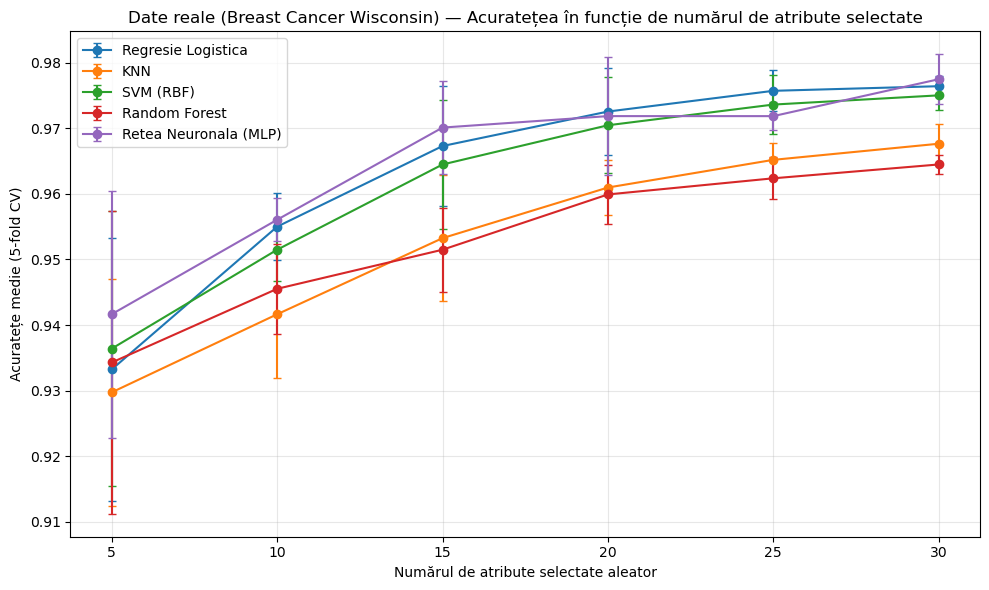

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
for m in df_uci_dim["model"].unique():
    sub = (df_uci_dim[df_uci_dim["model"] == m]
           .groupby("n_features")["accuracy_mean"]
           .agg(["mean", "std"]).reset_index())
    ax.errorbar(sub["n_features"], sub["mean"], yerr=sub["std"],
                marker="o", capsize=3, label=m)
ax.set_title("Date reale (Breast Cancer Wisconsin) — Acuratețea în funcție de "
             "numărul de atribute selectate")
ax.set_xlabel("Numărul de atribute selectate aleator")
ax.set_ylabel("Acuratețe medie (5-fold CV)")
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "uci_dimensionalitate.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.4. Comparație date sintetice vs date reale

Verificăm dacă **degradarea relativă** indusă de zgomot pe date reale este similară cu cea de pe date sintetice.

In [14]:
# Tendinte UCI — degradare totala
uci_drop = []
for m in df_uci_noise["model"].unique():
    sub = (df_uci_noise[df_uci_noise["model"] == m]
           .groupby("flip_y")["accuracy_mean"].mean())
    uci_drop.append({"model": m,
                     "acc_0.00_uci": sub.loc[0.00],
                     "acc_0.30_uci": sub.loc[0.30],
                     "degradare_uci": sub.loc[0.00] - sub.loc[0.30]})
uci_drop_df = pd.DataFrame(uci_drop).round(3)
print("Degradare la zgomot — date reale (Breast Cancer Wisconsin):\n")
print(uci_drop_df)


Degradare la zgomot — date reale (Breast Cancer Wisconsin):

                   model  acc_0.00_uci  acc_0.30_uci  degradare_uci
0     Regresie Logistica         0.976         0.654          0.322
1                    KNN         0.968         0.617          0.351
2              SVM (RBF)         0.975         0.669          0.306
3          Random Forest         0.963         0.650          0.314
4  Retea Neuronala (MLP)         0.975         0.610          0.366


## 5. Testare statistică — Friedman + post-hoc

Conform metodologiei standard pentru compararea multiplelor clasificatoare pe multiple seturi de date (Demšar, 2006):

1. **Testul Friedman** verifică ipoteza nulă că *toate cele 5 modele au aceeași performanță medie pe ranguri*.
2. Dacă H₀ este respinsă (p < 0.05), aplicăm **testul post-hoc Nemenyi** (sau Wilcoxon pe perechi cu corecție Holm) pentru a identifica perechile semnificativ diferite.

Datele de intrare: toate configurațiile experimentale (scenarii A, B, C, D) ca „blocuri”, iar modelele ca „grupuri”.


In [15]:
# Construim un dataframe unificat: fiecare RAND este o configuratie unica;
# coloanele sunt acuratetile celor 5 modele.

def build_blocks_from_scenario(df, param_cols):
    """Pivoteaza un DataFrame de scenariu astfel incat liniile sunt configuratii
    unice (val parametru + repetitie) si coloanele sunt modele."""
    df = df.copy()
    df["block_id"] = df[param_cols + ["repetitie"]].astype(str).agg("_".join, axis=1)
    pivot = df.pivot_table(index="block_id", columns="model", values="accuracy_mean")
    return pivot

# Adunam toate blocurile
blocks = []
# Scenariile A, B, C — daca CSV-urile exista deja, le citim
for fname, pcols in [
    ("scenariu_A_dimensionalitate.csv", ["n_features"]),
    ("scenariu_B_zgomot.csv", ["flip_y"]),
    ("scenariu_C_redundanta.csv", ["n_redundant"]),
]:
    fp = RESULTS_DIR / fname
    if fp.exists():
        sub_df = pd.read_csv(fp)
        blocks.append(build_blocks_from_scenario(sub_df, pcols))
        print(f"  Incarcat {fname}: {len(sub_df)} randuri")
    else:
        print(f"  AVERTISMENT: {fname} nu exista — ruleaza notebook-ul de baza intai.")

# Adaugam si Scenariul D
blocks.append(build_blocks_from_scenario(df_D, ["n_features", "flip_y"]))

# Combinam toate blocurile
all_blocks = pd.concat(blocks, axis=0)
all_blocks = all_blocks.dropna()
print(f"\nTotal blocuri (configuratii unice): {len(all_blocks)}")
print(f"Modele comparate: {list(all_blocks.columns)}")
all_blocks.head()


  Incarcat scenariu_A_dimensionalitate.csv: 175 randuri
  Incarcat scenariu_B_zgomot.csv: 175 randuri
  Incarcat scenariu_C_redundanta.csv: 175 randuri

Total blocuri (configuratii unice): 185
Modele comparate: ['KNN', 'Random Forest', 'Regresie Logistica', 'Retea Neuronala (MLP)', 'SVM (RBF)']


model,KNN,Random Forest,Regresie Logistica,Retea Neuronala (MLP),SVM (RBF)
block_id,,,,,
100_0,0.847,0.828,0.810,0.856,0.878
100_1,0.822,0.831,0.829,0.872,0.896
100_2,0.815,0.841,0.853,0.901,0.901
100_3,0.811,0.811,0.772,0.853,0.861
100_4,0.813,0.829,0.801,0.860,0.889


### 5.1. Testul Friedman

In [16]:
# Friedman test: ipoteza nula = toate modelele au aceeasi performanta medie pe ranguri
arrays = [all_blocks[col].values for col in all_blocks.columns]
stat, p_value = friedmanchisquare(*arrays)
print(f"Friedman χ² = {stat:.4f}")
print(f"p-value     = {p_value:.6f}")
print(f"N (blocuri) = {len(all_blocks)}, k (modele) = {len(all_blocks.columns)}")
if p_value < 0.05:
    print("\n>> Respingem H0: cel putin doua modele difera semnificativ (p < 0.05).")
    print("   Aplicam post-hoc pentru a identifica perechile.")
else:
    print("\n>> Nu putem respinge H0: nicio diferenta semnificativa detectata.")


Friedman χ² = 439.0569
p-value     = 0.000000
N (blocuri) = 185, k (modele) = 5

>> Respingem H0: cel putin doua modele difera semnificativ (p < 0.05).
   Aplicam post-hoc pentru a identifica perechile.


### 5.2. Rangurile medii — primul pas pentru analiza post-hoc

In [17]:
# Pentru fiecare bloc (linie), rangam modelele in functie de acuratete.
# Rangul 1 = cel mai bun model. Apoi calculam rangul mediu pe model.
ranks = all_blocks.apply(lambda row: rankdata(-row.values), axis=1, result_type='expand')
ranks.columns = all_blocks.columns
avg_ranks = ranks.mean().sort_values()
print("Rangul mediu (1 = cel mai bun):\n")
for m, r in avg_ranks.items():
    print(f"  {m:25s}: {r:.3f}")


Rangul mediu (1 = cel mai bun):

  SVM (RBF)                : 1.349
  Retea Neuronala (MLP)    : 2.351
  Random Forest            : 3.165
  KNN                      : 3.586
  Regresie Logistica       : 4.549


### 5.3. Critical Difference (Nemenyi)

Formula Demšar: `CD = qα × √(k(k+1) / (6N))`, unde qα este valoarea critică din distribuția Studentized Range pentru α=0.05.

Două modele cu o diferență de ranguri medii mai mare decât CD sunt **semnificativ diferite**.

In [18]:
# Valori critice qα pentru Nemenyi (α = 0.05) — tabel standard Demšar (2006)
# k = numarul de modele comparate
QALPHA_05 = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850, 7: 2.949,
             8: 3.031, 9: 3.102, 10: 3.164}

k = len(all_blocks.columns)
N = len(all_blocks)
q_alpha = QALPHA_05[k]
CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))
print(f"k = {k}, N = {N}, q_α = {q_alpha}")
print(f"Critical Difference (CD, α=0.05) = {CD:.4f}")

# Comparam toate perechile
print("\nPerechi semnificativ diferite (|diferenta de rang| > CD):\n")
models = avg_ranks.index.tolist()
significant_pairs = []
for i, m1 in enumerate(models):
    for m2 in models[i+1:]:
        diff = abs(avg_ranks[m1] - avg_ranks[m2])
        is_sig = "DA" if diff > CD else "nu"
        if diff > CD:
            significant_pairs.append((m1, m2, diff))
        print(f"  {m1:25s} vs {m2:25s} | Δrang = {diff:.3f} | semnificativ: {is_sig}")


k = 5, N = 185, q_α = 2.728
Critical Difference (CD, α=0.05) = 0.4485

Perechi semnificativ diferite (|diferenta de rang| > CD):

  SVM (RBF)                 vs Retea Neuronala (MLP)     | Δrang = 1.003 | semnificativ: DA
  SVM (RBF)                 vs Random Forest             | Δrang = 1.816 | semnificativ: DA
  SVM (RBF)                 vs KNN                       | Δrang = 2.238 | semnificativ: DA
  SVM (RBF)                 vs Regresie Logistica        | Δrang = 3.200 | semnificativ: DA
  Retea Neuronala (MLP)     vs Random Forest             | Δrang = 0.814 | semnificativ: DA
  Retea Neuronala (MLP)     vs KNN                       | Δrang = 1.235 | semnificativ: DA
  Retea Neuronala (MLP)     vs Regresie Logistica        | Δrang = 2.197 | semnificativ: DA
  Random Forest             vs KNN                       | Δrang = 0.422 | semnificativ: nu
  Random Forest             vs Regresie Logistica        | Δrang = 1.384 | semnificativ: DA
  KNN                       vs Regresie Lo

### 5.4. Critical Difference Diagram

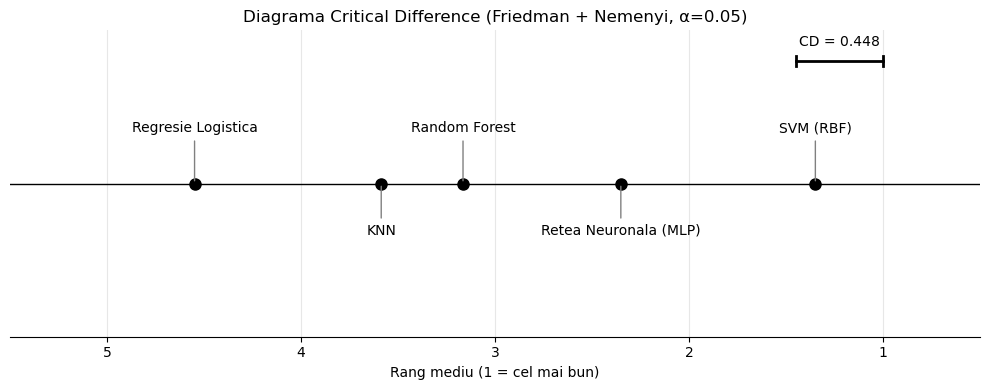

In [19]:
# Reprezentare grafica a rangurilor cu CD (Demšar diagram)
fig, ax = plt.subplots(figsize=(10, 4))

models_sorted = avg_ranks.index.tolist()
ranks_sorted = avg_ranks.values

# Bara orizontala de ranguri
ax.axhline(0, color='black', linewidth=1)
ax.set_xlim(0.5, k + 0.5)
ax.set_ylim(-1.5, 1.5)
ax.invert_xaxis()  # rangul 1 (cel mai bun) la stanga

# Marcam rangurile fiecarui model
for i, (m, r) in enumerate(zip(models_sorted, ranks_sorted)):
    ax.plot(r, 0, "ko", markersize=8)
    # alterneaza sus/jos pentru lizibilitate
    y_label = 0.5 if i % 2 == 0 else -0.5
    ax.annotate(m, (r, 0), xytext=(r, y_label),
                ha='center', fontsize=10,
                arrowprops=dict(arrowstyle='-', color='gray'))

# Bara CD
ax.plot([1.0, 1.0 + CD], [1.2, 1.2], "k-", linewidth=2)
ax.plot([1.0, 1.0], [1.15, 1.25], "k-", linewidth=2)
ax.plot([1.0 + CD, 1.0 + CD], [1.15, 1.25], "k-", linewidth=2)
ax.text(1.0 + CD/2, 1.35, f"CD = {CD:.3f}", ha='center', fontsize=10)

ax.set_xticks(range(1, k + 1))
ax.set_xlabel("Rang mediu (1 = cel mai bun)")
ax.set_yticks([])
ax.set_title("Diagrama Critical Difference (Friedman + Nemenyi, α=0.05)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "critical_difference_diagram.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.5. Confirmare prin Wilcoxon signed-rank cu corecție Holm

O a doua verificare post-hoc: pentru fiecare pereche de modele, aplicăm testul Wilcoxon (mai puternic decât Nemenyi când numărul de blocuri este mare) și corectăm pentru testele multiple cu metoda Holm.

In [20]:
from itertools import combinations

pairs = list(combinations(all_blocks.columns, 2))
pvals = []
for m1, m2 in pairs:
    stat_w, p_w = wilcoxon(all_blocks[m1], all_blocks[m2])
    pvals.append((m1, m2, p_w))

# Corectie Holm
pvals_sorted = sorted(pvals, key=lambda x: x[2])
n_tests = len(pvals_sorted)
print("Comparari pe perechi (Wilcoxon, p-value corectat Holm):\n")
print(f"{'Pereche':<55s} {'p (brut)':<12s} {'p (Holm)':<12s} {'Decizie':<15s}")
print("-" * 95)
for i, (m1, m2, p) in enumerate(pvals_sorted):
    p_holm = min(1.0, p * (n_tests - i))
    decision = "** semnificativ" if p_holm < 0.05 else "n.s."
    print(f"  {m1} vs {m2:<25s} {p:<12.4e} {p_holm:<12.4e} {decision}")


Comparari pe perechi (Wilcoxon, p-value corectat Holm):

Pereche                                                 p (brut)     p (Holm)     Decizie        
-----------------------------------------------------------------------------------------------
  Regresie Logistica vs SVM (RBF)                 4.3392e-32   4.3392e-31   ** semnificativ
  KNN vs SVM (RBF)                 2.2934e-31   2.0640e-30   ** semnificativ
  Regresie Logistica vs Retea Neuronala (MLP)     2.6806e-29   2.1445e-28   ** semnificativ
  Random Forest vs SVM (RBF)                 3.1853e-28   2.2297e-27   ** semnificativ
  Random Forest vs Regresie Logistica        3.8962e-25   2.3377e-24   ** semnificativ
  KNN vs Retea Neuronala (MLP)     1.4387e-20   7.1936e-20   ** semnificativ
  KNN vs Regresie Logistica        3.3885e-19   1.3554e-18   ** semnificativ
  Retea Neuronala (MLP) vs SVM (RBF)                 1.7888e-17   5.3663e-17   ** semnificativ
  Random Forest vs Retea Neuronala (MLP)     3.8282e-13   7.6564e

## 6. Sinteză finală

Această secțiune adună automat concluziile cantitative.


In [21]:
print("="*70)
print("SINTEZA TESTARII STATISTICE — pentru Capitolul 5")
print("="*70)

print(f"\n1. Testul Friedman pe {N} configuratii experimentale:")
print(f"   χ² = {stat:.4f}, p = {p_value:.6f}")
print(f"   Concluzie: {'cel putin doua modele difera semnificativ (p < 0.05).' if p_value < 0.05 else 'nicio diferenta semnificativa.'}")

print(f"\n2. Rangurile medii (Nemenyi, α=0.05, CD = {CD:.3f}):")
for m, r in avg_ranks.items():
    print(f"   {m:25s}: rang mediu = {r:.3f}")

print(f"\n3. Perechi cu diferenta semnificativa (CD = {CD:.3f}):")
if significant_pairs:
    for m1, m2, d in significant_pairs:
        print(f"   {m1} vs {m2}: Δrang = {d:.3f}")
else:
    print("   Niciuna detectata prin Nemenyi.")

print(f"\n4. Modelul de top dupa rangul mediu:")
top_model = avg_ranks.idxmin()
print(f"   {top_model} (rang mediu = {avg_ranks.min():.3f})")


SINTEZA TESTARII STATISTICE — pentru Capitolul 5

1. Testul Friedman pe 185 configuratii experimentale:
   χ² = 439.0569, p = 0.000000
   Concluzie: cel putin doua modele difera semnificativ (p < 0.05).

2. Rangurile medii (Nemenyi, α=0.05, CD = 0.448):
   SVM (RBF)                : rang mediu = 1.349
   Retea Neuronala (MLP)    : rang mediu = 2.351
   Random Forest            : rang mediu = 3.165
   KNN                      : rang mediu = 3.586
   Regresie Logistica       : rang mediu = 4.549

3. Perechi cu diferenta semnificativa (CD = 0.448):
   SVM (RBF) vs Retea Neuronala (MLP): Δrang = 1.003
   SVM (RBF) vs Random Forest: Δrang = 1.816
   SVM (RBF) vs KNN: Δrang = 2.238
   SVM (RBF) vs Regresie Logistica: Δrang = 3.200
   Retea Neuronala (MLP) vs Random Forest: Δrang = 0.814
   Retea Neuronala (MLP) vs KNN: Δrang = 1.235
   Retea Neuronala (MLP) vs Regresie Logistica: Δrang = 2.197
   Random Forest vs Regresie Logistica: Δrang = 1.384
   KNN vs Regresie Logistica: Δrang = 0.962



In [22]:
# Listeaza toate artefactele generate
print("Artefacte generate in folderul 'rezultate':\n")
for f in sorted(RESULTS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:50s} {size_kb:>8.1f} KB")


Artefacte generate in folderul 'rezultate':

  critical_difference_diagram.png                        40.5 KB
  heatmap_global.png                                     85.9 KB
  scenariu_A_accuracy.png                               143.1 KB
  scenariu_A_dimensionalitate.csv                        25.7 KB
  scenariu_A_std.png                                    137.4 KB
  scenariu_A_sumar.csv                                    1.9 KB
  scenariu_A_train_time.png                             100.8 KB
  scenariu_B_accuracy.png                               151.5 KB
  scenariu_B_auc.png                                    150.7 KB
  scenariu_B_f1.png                                     151.3 KB
  scenariu_B_sumar.csv                                    1.9 KB
  scenariu_B_zgomot.csv                                  25.9 KB
  scenariu_C_accuracy.png                               104.4 KB
  scenariu_C_redundanta.csv                              25.7 KB
  scenariu_C_std.png                         